In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms as T

In [2]:
current_dir = Path(os.getcwd())

if (current_dir.parent / "src").exists():
    PROJECT_ROOT = str(current_dir.parent)

elif (current_dir / "src").exists():
    PROJECT_ROOT = str(current_dir)

else:
    PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added project root to path: {PROJECT_ROOT}")

Added project root to path: /Users/shivakumarjagadish/Developer/Projects/Thermal-UAV


In [3]:
%load_ext dotenv
%dotenv

try:
    from src.data_pipeline import VedaiDataset
    from src.nuc import destripe_vertical

    print("Successfully imported src.data_pipeline and src.nuc")

except ImportError as e:
    print("\nFATAL ERROR: Could not import from 'src'.")
    print(
        "Please ensure your project is installed in editable mode (uv pip install -e .)"
    )
    raise e

Successfully imported src.data_pipeline and src.nuc


In [4]:
DATA_PATH_REL = os.environ.get("TEST_DATA_PATH")

if not DATA_PATH_REL:
    raise ValueError("TEST_DATA_PATH not set in .env file")

DATA_PATH = os.path.join(PROJECT_ROOT, DATA_PATH_REL)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

transform = T.Compose([T.ToTensor()])
dataset = VedaiDataset(root_dir=DATA_PATH, transform=transform)

print(f"Loaded {len(dataset)} images for NUC validation.")

Loaded 1246 images for NUC validation.


In [5]:
def validate_nuc(dataset_obj, idx, sigma=5.0, use_median=True):
    """
    Applies NUC destriping to a sample and visualizes the results.
    Crucially, it shows the 'Difference Map' to prove ONLY stripes were removed.
    """

    try:
        _, thermal_tensor, _ = dataset_obj[idx]

    except Exception as e:
        print(f"Error loading index {idx}: {e}")
        return

    cleaned_tensor = destripe_vertical(
        thermal_tensor, sigma=sigma, use_median=use_median
    )

    raw_np = thermal_tensor[0].numpy()
    clean_np = cleaned_tensor[0].numpy()

    noise_map = raw_np - clean_np

    fig, ax = plt.subplots(1, 3, figsize=(24, 8))

    vmin, vmax = np.percentile(raw_np, (1, 99))

    ax[0].imshow(raw_np, cmap="gray", vmin=vmin, vmax=vmax)
    ax[0].set_title(f"Original (Sample {idx})", fontsize=14)
    ax[0].axis("off")

    ax[1].imshow(clean_np, cmap="gray", vmin=vmin, vmax=vmax)
    ax[1].set_title(f"Destriped (sigma={sigma}, median={use_median})", fontsize=14)
    ax[1].axis("off")

    limit = np.max(np.abs(noise_map))
    im2 = ax[2].imshow(noise_map, cmap="coolwarm", vmin=-limit, vmax=limit)

    ax[2].set_title("Difference Map (What was removed)", fontsize=14)
    ax[2].axis("off")
    fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

--- Testing Gentle Settings (sigma=1.0) ---


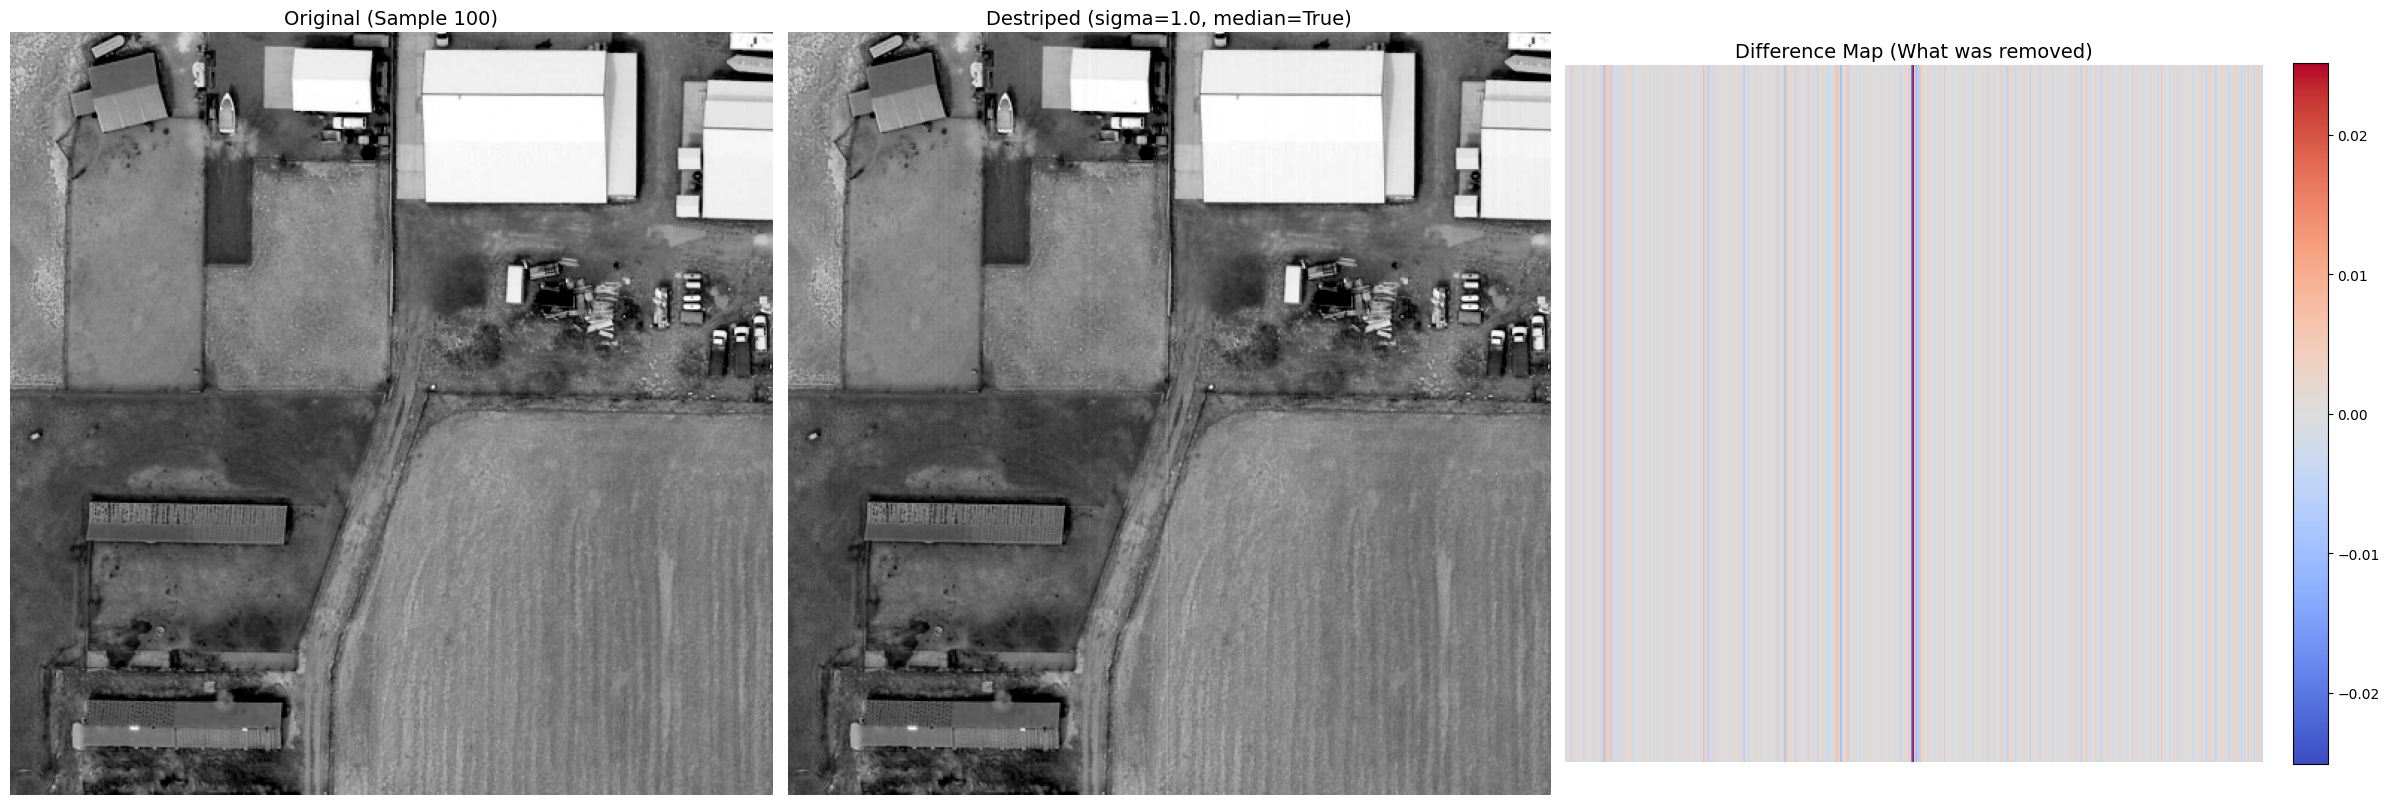

--- Testing Medium Settings (sigma=1.5) ---


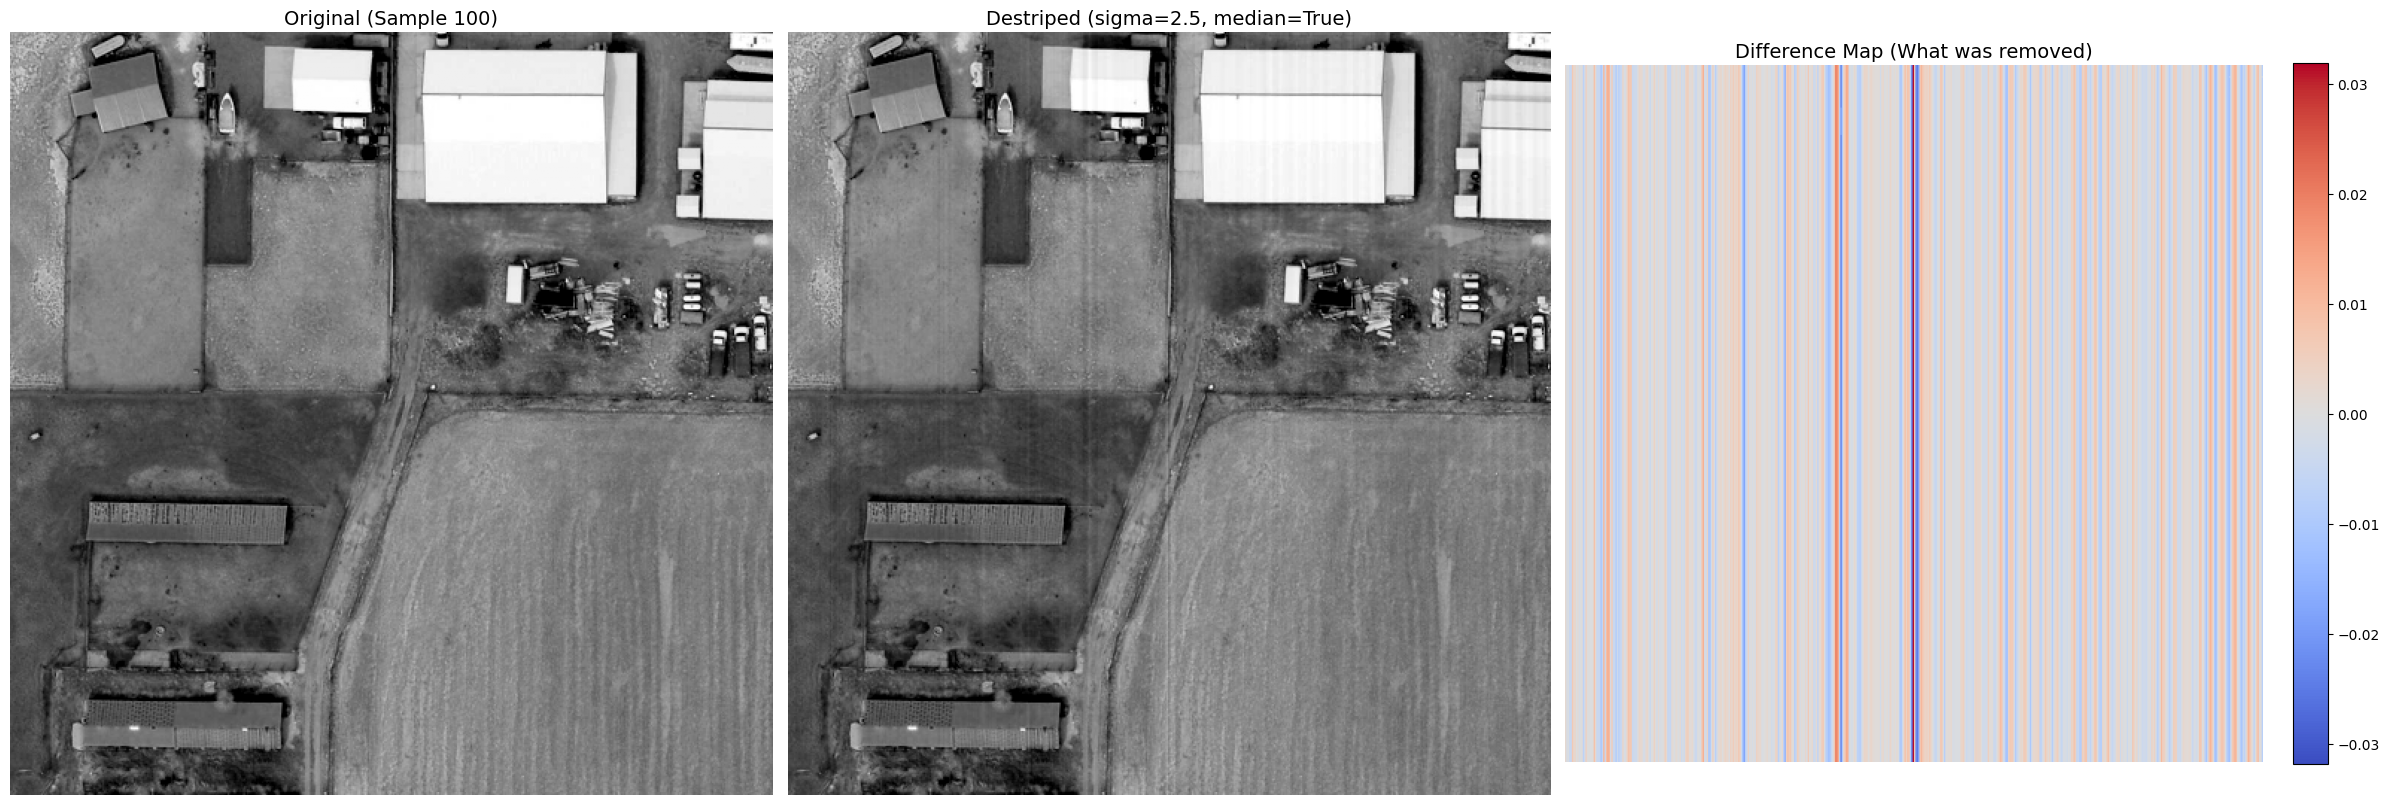

In [6]:
print("--- Testing Gentle Settings (sigma=1.0) ---")
validate_nuc(dataset, idx=100, sigma=1.0, use_median=True)

print("--- Testing Medium Settings (sigma=1.5) ---")
validate_nuc(dataset, idx=100, sigma=2.5, use_median=True)

# :)